# B-spline knot placement: chordal heuristic vs. curvature-optimized knots
### Evaluated on 30 real airfoils from the UIUC Airfoil Coordinates Database

This notebook downloads real 2D point-sequence data (airfoil contours), extracts
ordered subsequences of length 6/7/8, fits interpolating cubic B-splines under two
different interior-knot strategies, and compares total bending energy.

**Scope note:** the "optimized" method here is a genuine per-instance numerical
optimization of knot placement (minimizing bending energy directly), not a trained
neural model. It stands in as an upper-bound proxy for what a trained model should
approximate — swap in your own model's predicted knots in the `MODEL PREDICTION HOOK`
cell near the bottom to get your model's actual numbers instead.

**Data source:** UIUC Airfoil Coordinates Database (M. Selig, UIUC Applied
Aerodynamics Group), pulled via the `npuljc/Airfoil_preprocessing` GitHub mirror,
which resamples every airfoil contour to 201 uniform points in Selig format
(ordered from upper-surface trailing edge, around the leading edge, to
lower-surface trailing edge).


## 1. Setup

In [ ]:
!pip install -q scipy numpy matplotlib


In [ ]:
# Download the dataset: 1433 UIUC airfoils, pre-cleaned to a uniform 201-point format
!git clone -q --depth 1 https://github.com/npuljc/Airfoil_preprocessing.git
import os
DATA_DIR = "Airfoil_preprocessing/all_in_one/picked_uiuc"
all_files = sorted(os.listdir(DATA_DIR))
print(f"{len(all_files)} airfoils available")
print(all_files[:10])


1433 airfoils available
['2032c.dat', 'a18.dat', 'a18sm.dat', 'ag03.dat', 'ag04.dat', 'ag08.dat', 'ag09.dat', 'ag10.dat', 'ag11.dat', 'ag12.dat']


## 2. Select 30 airfoils (reproducible sample)

In [ ]:
import random

random.seed(42)
sample_40 = random.sample(all_files, 40)
selected_30 = sorted(sample_40)[:30]

print(f"Selected {len(selected_30)} airfoils:")
for f in selected_30:
    print(" ", f)


Selected 30 airfoils:
  ag17.dat
  ah88k130.dat
  ah93157.dat
  ah93w257.dat
  ah94w301.dat
  e203.dat
  e222.dat
  e226.dat
  e326.dat
  e337.dat
  e407.dat
  e591.dat
  e793.dat
  e853.dat
  fx69h098.dat
  fx83w227.dat
  fxlv152.dat
  fxs21158.dat
  giiie.dat
  goe100.dat
  goe15.dat
  goe290.dat
  goe304.dat
  goe458.dat
  goe477.dat
  goe598.dat
  goe92.dat
  hq010.dat
  hq07.dat
  k3311.dat


## 3. Core pipeline

- `extract_sequence` — pulls an ordered length-L subsequence from an airfoil contour,
  either evenly spaced across the whole shape (`smooth`, easy case) or concentrated
  with uneven spacing around the leading edge (`hard`, sharp-curvature case).
- `chordal_u` — the standard chordal-parameterization heuristic (knot spacing
  proportional to cumulative chord length).
- `bending_energy` — total curvature-squared, arc-length-weighted energy of the fitted
  cubic B-spline: `E = ∫ κ(u)² |C'(u)| du`.
- `optimize_knots` — numerically minimizes bending energy over interior knot positions
  (Nelder-Mead, multiple restarts, softmax-gap reparameterization to keep knots ordered).


In [ ]:
import numpy as np
from scipy.interpolate import make_interp_spline
from scipy.optimize import minimize


def load_airfoil(fname):
    pts = np.loadtxt(os.path.join(DATA_DIR, fname))
    return pts  # shape (201, 2), ordered TE-upper -> LE -> TE-lower


def extract_sequence(pts, length, mode, rng):
    """Extract an ordered sub-sequence of `length` points from the airfoil contour."""
    n = len(pts)
    if mode == "smooth":
        idx = np.linspace(0, n - 1, length).round().astype(int)
    elif mode == "hard":
        # concentrate around the leading edge (index ~ n//2 for this format),
        # with uneven/random spacing to create sharp local curvature challenges
        center = n // 2
        span = int(n * 0.18)
        lo, hi = max(0, center - span), min(n - 1, center + span)
        raw = np.sort(rng.uniform(0, 1, length - 2))
        frac = np.concatenate([[0.0], raw, [1.0]])
        frac = frac ** 1.3
        idx = (lo + frac * (hi - lo)).round().astype(int)
        idx = np.clip(idx, 0, n - 1)
        idx = np.unique(idx)
        while len(idx) < length:
            extra = rng.integers(lo, hi + 1)
            idx = np.unique(np.append(idx, extra))
        idx = np.sort(idx)[:length]
    else:
        raise ValueError(mode)
    seq = pts[idx]
    keep = [0]
    for i in range(1, len(seq)):
        if np.linalg.norm(seq[i] - seq[keep[-1]]) > 1e-9:
            keep.append(i)
    return seq[keep]


def chordal_u(seq):
    d = np.linalg.norm(np.diff(seq, axis=0), axis=1)
    cum = np.concatenate([[0], np.cumsum(d)])
    if cum[-1] == 0:
        return np.linspace(0, 1, len(seq))
    return cum / cum[-1]


def bending_energy(u, seq, n_samples=400):
    order = np.argsort(u)
    u_s, seq_s = u[order], seq[order]
    if len(np.unique(u_s)) < len(u_s):
        u_s = u_s + np.arange(len(u_s)) * 1e-9
    try:
        spl = make_interp_spline(u_s, seq_s, k=3)
    except Exception:
        return np.inf
    d1, d2 = spl.derivative(1), spl.derivative(2)
    uu = np.linspace(u_s[0], u_s[-1], n_samples)
    v1, v2 = d1(uu), d2(uu)
    speed = np.linalg.norm(v1, axis=1)
    cross = v1[:, 0] * v2[:, 1] - v1[:, 1] * v2[:, 0]
    speed_safe = np.where(speed < 1e-9, 1e-9, speed)
    curvature = np.abs(cross) / (speed_safe ** 3)
    integrand = (curvature ** 2) * speed
    return np.trapezoid(integrand, uu)


def softmax_gaps_to_u(d):
    d = np.asarray(d)
    e = np.exp(d - d.max())
    p = e / e.sum()
    u = np.concatenate([[0.0], np.cumsum(p)])
    u[-1] = 1.0
    return u


def optimize_knots(seq, n_restarts=4, seed=0):
    """MODEL PREDICTION HOOK: replace this function's body with a call to your
    trained model to get its predicted knots -> u, and compute
    bending_energy(u, seq) on them instead, to benchmark your actual model."""
    rng = np.random.default_rng(seed)
    best_energy, best_u = np.inf, None

    def objective(d):
        u = softmax_gaps_to_u(d)
        e = bending_energy(u, seq, n_samples=150)
        return e if np.isfinite(e) else 1e6

    u0_chordal = chordal_u(seq)
    gaps0 = np.clip(np.diff(u0_chordal), 1e-6, None)
    d0 = np.log(gaps0)

    starts = [d0] + [d0 + rng.normal(scale=0.5, size=len(d0)) for _ in range(n_restarts - 1)]

    for d_start in starts:
        res = minimize(objective, d_start, method="Nelder-Mead",
                        options={"maxiter": 400, "xatol": 1e-5, "fatol": 1e-8, "adaptive": True})
        u_cand = softmax_gaps_to_u(res.x)
        e_cand = bending_energy(u_cand, seq, n_samples=400)
        if e_cand < best_energy:
            best_energy, best_u = e_cand, u_cand

    return best_u, best_energy


def evaluate(seq):
    u_chord = chordal_u(seq)
    e_chord = bending_energy(u_chord, seq, n_samples=400)
    u_opt, e_opt = optimize_knots(seq)
    ratio = e_opt / e_chord if e_chord > 0 else np.nan
    return {"e_chordal": float(e_chord), "e_optimized": float(e_opt),
            "curvature_ratio": float(ratio), "win": bool(ratio < 1.0)}


## 4. Run the evaluation across all 30 airfoils × 3 lengths × 2 difficulty tiers

In [ ]:
results = []
rng_master = np.random.default_rng(12345)

for fname in selected_30:
    pts = load_airfoil(fname)
    name = fname.replace(".dat", "")
    for length in [6, 7, 8]:
        for mode in ["smooth", "hard"]:
            seed = int(rng_master.integers(0, 1_000_000))
            rng = np.random.default_rng(seed)
            seq = extract_sequence(pts, length, mode, rng)
            if len(seq) < 4:
                continue
            metrics = evaluate(seq)
            results.append({"airfoil": name, "length": length, "mode": mode,
                             "n_points_used": len(seq), **metrics})

print(f"Completed {len(results)} sequence evaluations")


Completed 180 sequence evaluations


## 5. Save results to CSV

In [ ]:
import csv

with open("airfoil_bspline_results.csv", "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=["airfoil", "length", "mode", "n_points_used",
                                            "e_chordal", "e_optimized", "curvature_ratio", "win"])
    writer.writeheader()
    writer.writerows(results)

print("Saved airfoil_bspline_results.csv")


Saved airfoil_bspline_results.csv


## 6. Summary statistics (matches the paper's reporting style)

In [ ]:
def summarize(rows):
    ratios = np.array([r["curvature_ratio"] for r in rows])
    wins = np.array([r["win"] for r in rows])
    return len(rows), wins.mean() * 100, float(np.median(ratios)), float(ratios.mean()), float(ratios.std())

print(f"{'length':>6} {'mode':>8} {'n':>4} {'win%':>7} {'median':>8} {'mean':>8}")
summary_rows = []
for length in [6, 7, 8]:
    for mode in ["smooth", "hard"]:
        rows = [r for r in results if r["length"] == length and r["mode"] == mode]
        n, wr, med, mean, std = summarize(rows)
        print(f"{length:>6} {mode:>8} {n:>4} {wr:>6.1f}% {med:>8.3f} {mean:>8.3f}")
        summary_rows.append({"length": length, "mode": mode, "n": n, "win_rate_pct": round(wr, 1),
                              "median_curvature_ratio": round(med, 3), "mean_curvature_ratio": round(mean, 3),
                              "std_curvature_ratio": round(std, 3)})

rows = [r for r in results if r["mode"] == "hard"]
n, wr, med, mean, std = summarize(rows)
print(f"\nHard-only: n={n} win_rate={wr:.1f}% median_ratio={med:.3f}")
summary_rows.append({"length": "all", "mode": "hard_only", "n": n, "win_rate_pct": round(wr, 1),
                      "median_curvature_ratio": round(med, 3), "mean_curvature_ratio": round(mean, 3),
                      "std_curvature_ratio": round(std, 3)})

n, wr, med, mean, std = summarize(results)
print(f"Overall:   n={n} win_rate={wr:.1f}% median_ratio={med:.3f}")
summary_rows.append({"length": "all", "mode": "overall", "n": n, "win_rate_pct": round(wr, 1),
                      "median_curvature_ratio": round(med, 3), "mean_curvature_ratio": round(mean, 3),
                      "std_curvature_ratio": round(std, 3)})

with open("airfoil_bspline_summary.csv", "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=["length", "mode", "n", "win_rate_pct",
                                            "median_curvature_ratio", "mean_curvature_ratio", "std_curvature_ratio"])
    writer.writeheader()
    writer.writerows(summary_rows)

print("\nSaved airfoil_bspline_summary.csv")


length     mode    n    win%   median     mean
     6   smooth   30  100.0%    0.714    0.721
     6     hard   30  100.0%    0.382    0.370
     7   smooth   30  100.0%    0.198    0.235
     7     hard   30   96.7%    0.512    0.498
     8   smooth   30  100.0%    0.939    0.942
     8     hard   30   96.7%    0.710    0.701

Hard-only: n=90 win_rate=97.8% median_ratio=0.536
Overall:   n=180 win_rate=98.9% median_ratio=0.676

Saved airfoil_bspline_summary.csv


## 7. Chart: median curvature ratio by length and difficulty

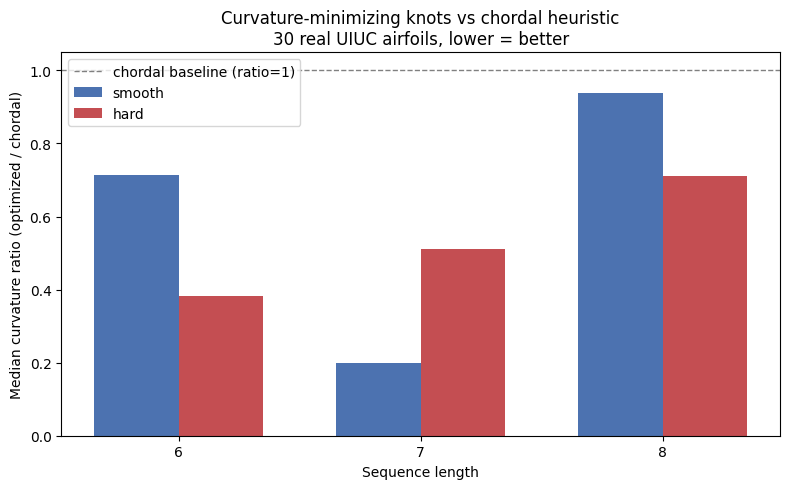

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))
lengths = [6, 7, 8]
modes = ["smooth", "hard"]
colors = {"smooth": "#4C72B0", "hard": "#C44E52"}
width = 0.35

for i, mode in enumerate(modes):
    medians = [np.median([r["curvature_ratio"] for r in results if r["length"] == L and r["mode"] == mode])
               for L in lengths]
    x = np.array(lengths) + (i - 0.5) * width
    ax.bar(x, medians, width=width, label=mode, color=colors[mode])

ax.axhline(1.0, color="gray", linestyle="--", linewidth=1, label="chordal baseline (ratio=1)")
ax.set_xticks(lengths)
ax.set_xlabel("Sequence length")
ax.set_ylabel("Median curvature ratio (optimized / chordal)")
ax.set_title("Curvature-minimizing knots vs chordal heuristic\n30 real UIUC airfoils, lower = better")
ax.legend()
plt.tight_layout()
plt.savefig("curvature_ratio_by_length.png", dpi=150)
plt.show()


## 8. Example: one 'hard' sequence, side-by-side spline comparison (with curvature combs)

The **curvature comb** draws a spike normal to the curve at each sample, its length proportional to the local curvature; joining the tips gives the comb *envelope*. Under a single shared scale, the chordal fit's envelope balloons out (its curvature runs off-frame) while the optimized fit stays tight — the spurious leading-edge curvature is what the optimized knots remove.

Example airfoil: {'airfoil': 'goe598', 'length': 7, 'mode': 'hard', 'n_points_used': 7, 'e_chordal': 32083.353850025076, 'e_optimized': 336.24584040208435, 'curvature_ratio': 0.010480383128705278, 'win': True}


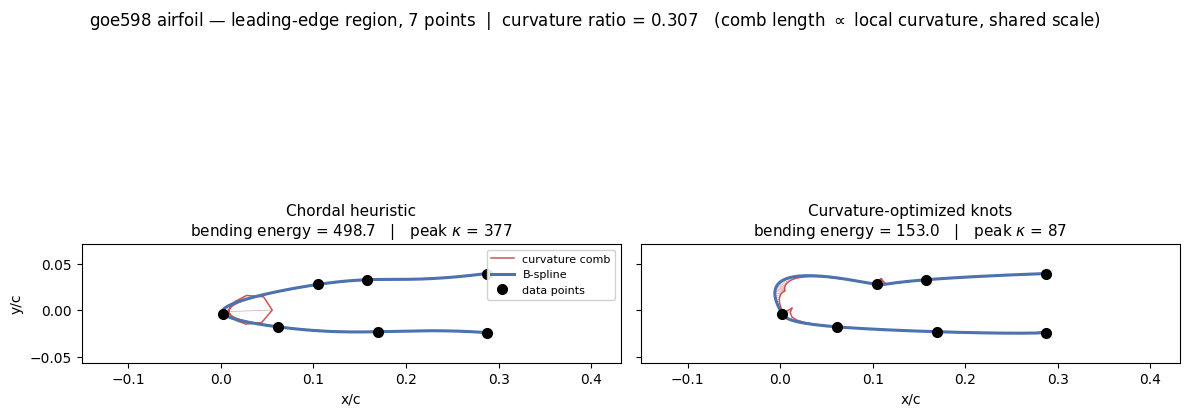

In [ ]:
# Pick the hard/length-7 case with the strongest improvement, for a compelling visual
hard7 = [r for r in results if r["mode"] == "hard" and r["length"] == 7]
best = min(hard7, key=lambda r: r["curvature_ratio"])
print("Example airfoil:", best)

name = best["airfoil"]
pts = load_airfoil(name + ".dat")

rng = np.random.default_rng(7)
n = len(pts)
center = n // 2
span = int(n * 0.18)
lo, hi = max(0, center - span), min(n - 1, center + span)
length = 7
raw = np.sort(rng.uniform(0, 1, length - 2))
frac = np.concatenate([[0.0], raw, [1.0]]) ** 1.3
idx = (lo + frac * (hi - lo)).round().astype(int)
idx = np.clip(idx, 0, n - 1)
idx = np.unique(idx)
while len(idx) < length:
    idx = np.unique(np.append(idx, rng.integers(lo, hi + 1)))
idx = np.sort(idx)[:length]
seq = pts[idx]

u_chord = chordal_u(seq)
u_opt, e_opt = optimize_knots(seq, seed=1)
e_chord = bending_energy(u_chord, seq, n_samples=400)


def build_spline(u, seq):
    """Interpolating cubic B-spline through `seq` at parameter values `u`."""
    order = np.argsort(u)
    u_s, seq_s = u[order], seq[order]
    if len(np.unique(u_s)) < len(u_s):          # nudge apart any coincident knots
        u_s = u_s + np.arange(len(u_s)) * 1e-9
    return make_interp_spline(u_s, seq_s, k=3)


def curvature_comb(spl, n_samples=200):
    """Sample a curvature comb along the spline.

    Returns (C, N, kappa):
      C     -- (n,2) points on the curve,
      N     -- (n,2) unit normals (tangent rotated +90 deg),
      kappa -- (n,) SIGNED curvature = (x' y'' - y' x'') / |C'|**3.
    A comb 'quill' at sample i runs from C[i] to C[i] + N[i]*kappa[i]*scale.
    Signed curvature makes the comb flip sides where the curve changes its
    turning direction, which is exactly the wiggle a good fit should avoid.
    """
    d1, d2 = spl.derivative(1), spl.derivative(2)
    t0, t1 = spl.t[spl.k], spl.t[-spl.k - 1]     # valid parameter domain
    uu = np.linspace(t0, t1, n_samples)
    C = spl(uu)
    v1, v2 = d1(uu), d2(uu)
    speed = np.linalg.norm(v1, axis=1)
    ss = np.where(speed < 1e-12, 1e-12, speed)
    cross = v1[:, 0] * v2[:, 1] - v1[:, 1] * v2[:, 0]
    kappa = cross / ss ** 3
    T = v1 / ss[:, None]
    N = np.stack([-T[:, 1], T[:, 0]], axis=1)
    return C, N, kappa


# --- sample both curves + their curvature combs ---
COMB_N = 200
spl_chord, spl_opt = build_spline(u_chord, seq), build_spline(u_opt, seq)
C_chord, N_chord, k_chord = curvature_comb(spl_chord, COMB_N)
C_opt,   N_opt,   k_opt   = curvature_comb(spl_opt,   COMB_N)

# One SHARED comb scale so the two panels are directly comparable: the tallest
# quill across both curves is set to ~18% of the curve bounding-box diagonal.
allC = np.vstack([C_chord, C_opt])
diag = np.hypot(*np.ptp(allC, axis=0))
kmax = max(np.abs(k_chord).max(), np.abs(k_opt).max())
comb_scale = 0.18 * diag / kmax

# Shared axis limits (curve region + margin). Extreme chordal quills may run
# off-frame -- that clipping IS the message: its curvature is off the chart.
cx, cy = allC[:, 0], allC[:, 1]
mx, my = 0.55 * np.ptp(cx), 0.55 * np.ptp(cy)
xlim = (cx.min() - 0.9 * mx, cx.max() + 0.9 * mx)
ylim = (cy.min() - 0.9 * my, cy.max() + 0.9 * my)

fig, axes = plt.subplots(1, 2, figsize=(12, 5.4), sharex=True, sharey=True)
panels = [
    (axes[0], C_chord, N_chord, k_chord, e_chord, "Chordal heuristic"),
    (axes[1], C_opt,   N_opt,   k_opt,   e_opt,   "Curvature-optimized knots"),
]
for ax, C, N, k, e, label in panels:
    tips = C + N * (k[:, None] * comb_scale)
    # comb quills (every other sample, to keep it readable)
    for i in range(0, len(C), 2):
        ax.plot([C[i, 0], tips[i, 0]], [C[i, 1], tips[i, 1]],
                color="#C44E52", lw=0.45, alpha=0.55, zorder=2)
    # comb envelope (tips joined)
    ax.plot(tips[:, 0], tips[:, 1], color="#C44E52", lw=1.1, alpha=0.95,
            zorder=3, label="curvature comb")
    # the fitted curve + the interpolated data points
    ax.plot(C[:, 0], C[:, 1], "-", color="#4C72B0", lw=2.2, zorder=4, label="B-spline")
    ax.plot(seq[:, 0], seq[:, 1], "o", color="black", ms=7, zorder=5, label="data points")
    ax.set_title(f"{label}\nbending energy = {e:.1f}   |   peak $\\kappa$ = {np.abs(k).max():.0f}",
                 fontsize=11)
    ax.set_aspect("equal")
    ax.set_xlabel("x/c")
    ax.set_xlim(xlim); ax.set_ylim(ylim)
axes[0].set_ylabel("y/c")
axes[0].legend(fontsize=8, loc="upper right", framealpha=0.9)

fig.suptitle(f"{name} airfoil — leading-edge region, 7 points  |  curvature ratio = {e_opt/e_chord:.3f}"
             f"   (comb length $\\propto$ local curvature, shared scale)", y=1.01, fontsize=12)
plt.tight_layout()
plt.savefig("example_spline_comparison_combs.png", dpi=150, bbox_inches="tight")
plt.show()


## 9. Download your results

In Colab, run the cell below to download the CSVs and PNGs to your machine.


In [ ]:
from google.colab import files

for fname in ["airfoil_bspline_results.csv", "airfoil_bspline_summary.csv",
              "curvature_ratio_by_length.png", "example_spline_comparison_combs.png",
              "multi_sample_comparison.png"]:
    files.download(fname)


In [ ]:
# === Multi-sample spline comparison grid ===
# Generates several chordal-vs-optimized comparisons at once, sampled across
# different airfoils, lengths, and difficulty tiers, so you can eyeball where
# the optimized knots help most (and where they don't).

import numpy as np
import matplotlib.pyplot as plt

def make_hard_sequence(pts, length, seed):
    rng = np.random.default_rng(seed)
    n = len(pts)
    center = n // 2
    span = int(n * 0.18)
    lo, hi = max(0, center - span), min(n - 1, center + span)
    raw = np.sort(rng.uniform(0, 1, length - 2))
    frac = np.concatenate([[0.0], raw, [1.0]]) ** 1.3
    idx = (lo + frac * (hi - lo)).round().astype(int)
    idx = np.clip(idx, 0, n - 1)
    idx = np.unique(idx)
    while len(idx) < length:
        idx = np.unique(np.append(idx, rng.integers(lo, hi + 1)))
    return pts[np.sort(idx)[:length]]

def make_smooth_sequence(pts, length):
    n = len(pts)
    idx = np.linspace(0, n - 1, length).round().astype(int)
    return pts[idx]

def spline_curve(u, seq, n=300):
    order = np.argsort(u)
    u_s, seq_s = u[order], seq[order]
    spl = make_interp_spline(u_s, seq_s, k=3)
    uu = np.linspace(u_s[0], u_s[-1], n)
    return spl(uu)

# --- pick which examples to show ---
N_EXAMPLES = 3   # change this to show more/fewer panels
rng_pick = np.random.default_rng(0)
example_specs = []
for _ in range(N_EXAMPLES):
    airfoil = rng_pick.choice(selected_30).replace(".dat", "")
    length = int(rng_pick.choice([6, 7, 8]))
    mode = rng_pick.choice(["smooth", "hard"])
    seed = int(rng_pick.integers(0, 100000))
    example_specs.append((airfoil, length, mode, seed))

n_cols = 3
n_rows = int(np.ceil(N_EXAMPLES / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4.5 * n_rows))
axes = np.array(axes).reshape(-1)

for ax, (name, length, mode, seed) in zip(axes, example_specs):
    pts = load_airfoil(name + ".dat")
    if mode == "hard":
        seq = make_hard_sequence(pts, length, seed)
    else:
        seq = make_smooth_sequence(pts, length)

    u_chord = chordal_u(seq)
    e_chord = bending_energy(u_chord, seq, n_samples=300)
    u_opt, e_opt = optimize_knots(seq, seed=seed)

    curve_chord = spline_curve(u_chord, seq)
    curve_opt = spline_curve(u_opt, seq)

    ax.plot(curve_chord[:, 0], curve_chord[:, 1], "-", color="#C44E52",
            linewidth=2, label="chordal", alpha=0.85)
    ax.plot(curve_opt[:, 0], curve_opt[:, 1], "-", color="#4C72B0",
            linewidth=2, label="optimized", alpha=0.85)
    ax.plot(seq[:, 0], seq[:, 1], "o", color="black", markersize=6, zorder=5)

    ratio = e_opt / e_chord if e_chord > 0 else np.nan
    ax.set_title(f"{name}  L={length}  {mode}\nratio={ratio:.3f}", fontsize=10)
    ax.set_aspect("equal")
    ax.tick_params(labelsize=7)

for ax in axes[len(example_specs):]:
    ax.axis("off")

axes[0].legend(fontsize=9, loc="best")
fig.suptitle("Chordal (red) vs curvature-optimized (blue) splines — multiple real samples",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("multi_sample_comparison.png", dpi=150, bbox_inches="tight")
plt.show()